<a href="https://colab.research.google.com/github/Vedanshi18/inventory-demand-forecasting/blob/main/Inventory_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing necessary libraries and dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae

import warnings
warnings.filterwarnings('ignore')

Load and export dataset

In [4]:
df = pd.read_csv("train.csv")
display(df.head())
display(df.tail())

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [6]:
df.shape

(913000, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [8]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


Feature Engineering

In [10]:
parts = df["date"].str.split("-", n =3, expand = True)
df["year"] = parts[0].astype('int')
df["month"] = parts[1].astype('int')
df["day"] = parts[2].astype('int')
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


checking the effect of day on requirements to fulfill the demands

checking weekend/ weekday :

In [15]:
from datetime import datetime

def weekend_or_weekday(year, month, day):
  d = datetime(year, month, day)
  # 1 == weekend & 0 == weekday
  #d.weekday is a built-in method of datetime object
  return 1 if d.weekday() > 4 else 0


#df.apply() --> iterates through each row of the DataFrame and applies the weekend_or_weekday function to the relevant columns of that row,
#               returning a new DataFrame which is then assigned to the 'weekend' column.
# axis 1 = row-wise, axis 0 = column-wise
df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis =1)

df.head()

,date,store,item,sales,year,month,day,weekend
0,2013-01-01,1,1,13,2013,1,1,0
1,2013-01-02,1,1,11,2013,1,2,0
2,2013-01-03,1,1,14,2013,1,3,0
3,2013-01-04,1,1,13,2013,1,4,0
4,2013-01-05,1,1,10,2013,1,5,1


checking for holiday

In [20]:
from datetime import date
import holidays

india_holidays = holidays.country_holidays('IN')
# 1 == holiday in india, 0 == not holiday
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)

display(df.head())

# Display the row for August 15, 2013 to check the holiday flag
display(df[df['date'] == '2013-08-15'])

,date,store,item,sales,year,month,day,weekend,holidays
0,2013-01-01,1,1,13,2013,1,1,0,0
1,2013-01-02,1,1,11,2013,1,2,0,0
2,2013-01-03,1,1,14,2013,1,3,0,0
3,2013-01-04,1,1,13,2013,1,4,0,0
4,2013-01-05,1,1,10,2013,1,5,1,0


,date,store,item,sales,year,month,day,weekend,holidays
226,2013-08-15,1,1,22,2013,8,15,0,1
2052,2013-08-15,2,1,26,2013,8,15,0,1
3878,2013-08-15,3,1,23,2013,8,15,0,1
5704,2013-08-15,4,1,12,2013,8,15,0,1
7530,2013-08-15,5,1,21,2013,8,15,0,1
...,...,...,...,...,...,...,...,...,...
904096,2013-08-15,6,50,48,2013,8,15,0,1
905922,2013-08-15,7,50,41,2013,8,15,0,1
907748,2013-08-15,8,50,60,2013,8,15,0,1
909574,2013-08-15,9,50,68,2013,8,15,0,1


generally used in machine learning tasks, especially when dealing with time-series data or any feature that is inherently cyclical. Common applications include:

**Time Series Forecasting**: Predicting sales, weather, energy consumption, etc., where daily, weekly, monthly, or yearly patterns are crucial. <br>
**Demand Prediction**: As in your current dataset, predicting sales often has strong monthly or seasonal components. <br>
**Recommendation Systems**: Understanding seasonal preferences for products. <br>
**Any model that struggles with ordinal cyclical data**: Linear models (like Linear Regression, Ridge, Lasso) and tree-based models (like Random Forest, XGBoost) can benefit significantly. For example, a linear model would see month 12 as numerically very far from month 1, potentially missing the actual closeness in time. These sine/cosine features solve that problem.

This code is performing feature engineering on the 'month' column to handle its cyclical nature. Months are cyclical (January follows December), so a simple numerical representation might not capture this relationship well. Transforming them using sine and cosine functions allows machine learning models to understand this cyclical pattern.

 For example, month 1 (January) would be mapped to an angle, and month 12 (December) would be mapped to an angle close to month 1, capturing the cyclical relationship.

In [22]:
#
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))
df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025


indicating which day of the week it is

In [23]:
def which_day(year, month, day):
  return datetime(year, month, day).weekday()

df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis =1)

df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025,1
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025,2
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025,3
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025,4
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025,5


removing columns that are not useful

In [24]:
df.drop('date', axis=1, inplace=True)

df.head()

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13,2013,1,1,0,0,0.5,0.866025,1
1,1,1,11,2013,1,2,0,0,0.5,0.866025,2
2,1,1,14,2013,1,3,0,0,0.5,0.866025,3
3,1,1,13,2013,1,4,0,0,0.5,0.866025,4
4,1,1,10,2013,1,5,1,0,0.5,0.866025,5


Exploratory data analysis : used to discover trends, and patterns or to check assumptions with the help of statistical summaries and graphical representations

In [25]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

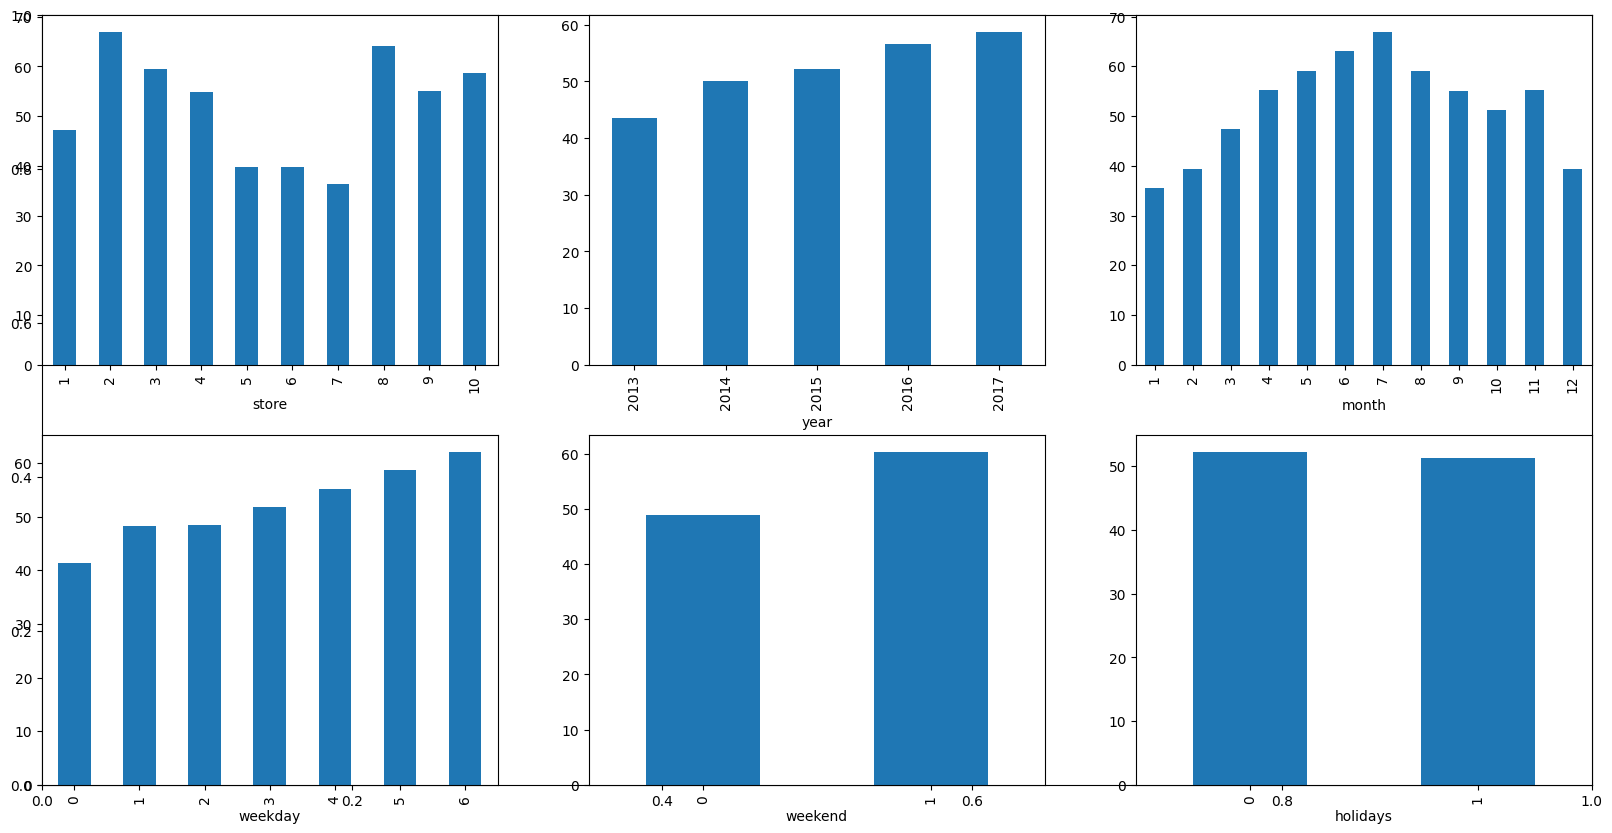

In [26]:
# groups the data by current column and calculate the mean sales of each group and plot a bar chart to show the averages for each category of features.

df['weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

plt.subplots(figsize = (20,10))
for i, col in enumerate(features):
  plt.subplot(2, 3, i+1)
  df.groupby(col).mean()['sales'].plot.bar()
plt.show()